*Fake News Detection Model*

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import joblib
from collections import Counter
import re
from scipy.sparse import hstack

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [147]:
fake = pd.read_csv("datasets/Fake.csv")
true = pd.read_csv("datasets/True.csv")
print('Fake news shape:', fake.shape)
print('Real news shape:', true.shape)

Fake news shape: (23481, 4)
Real news shape: (21417, 4)


In [148]:
fake["label"] = 1
true["label"] = 0

data = pd.concat([fake, true], ignore_index=True)
print('Combined dataset shape:', data.shape)

Combined dataset shape: (44898, 5)


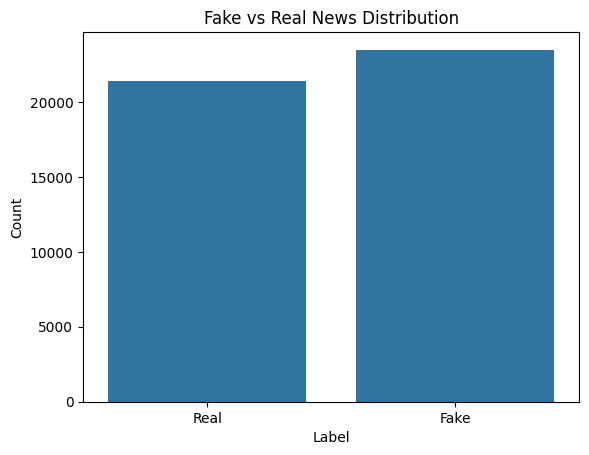

In [149]:
sns.countplot(x='label', data=data)
plt.title('Fake vs Real News Distribution')
plt.xticks([0, 1], ['Real', 'Fake'])
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

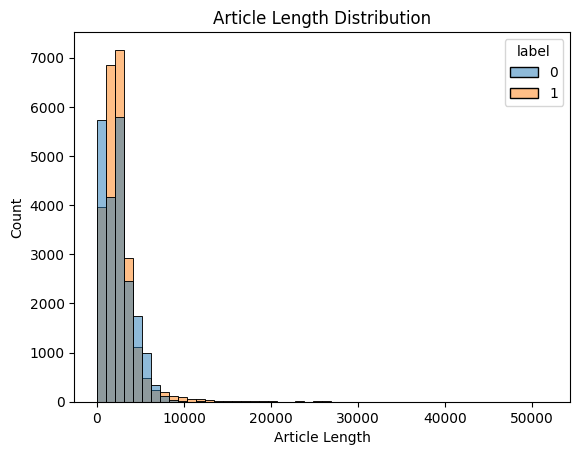

In [150]:
data['text_length'] = data['text'].apply(len)
sns.histplot(data=data, x='text_length', hue='label', bins=50)
plt.title('Article Length Distribution')
plt.xlabel('Article Length')
plt.ylabel('Count')
plt.show()

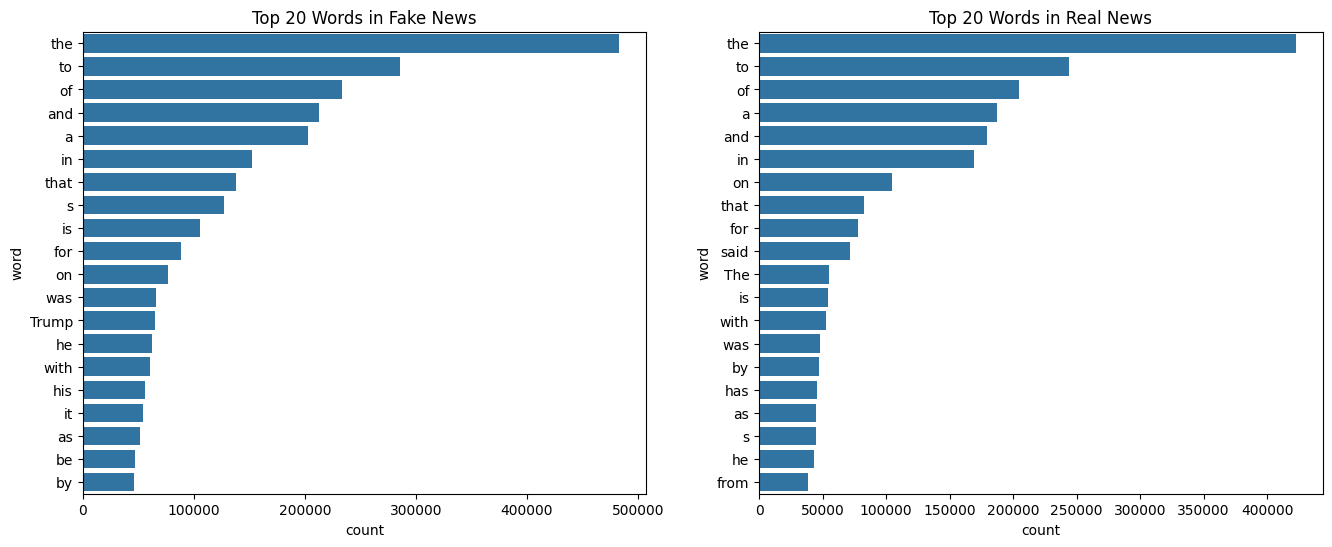

In [151]:
fake_words = ' '.join(data[data['label'] == 1]['text']).split()
real_words = ' '.join(data[data['label'] == 0]['text']).split()

fake_freq = Counter(fake_words).most_common(20)
real_freq = Counter(real_words).most_common(20)

fake_df = pd.DataFrame(fake_freq, columns=['word', 'count'])
real_df = pd.DataFrame(real_freq, columns=['word', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x='count', y='word', data=fake_df, ax=axes[0])
axes[0].set_title('Top 20 Words in Fake News')
sns.barplot(x='count', y='word', data=real_df, ax=axes[1])
axes[1].set_title('Top 20 Words in Real News')
plt.show()

In [152]:
print("Missing values:\n", data.isnull().sum())
print("\nDuplicate rows:", data.duplicated().sum())

Missing values:
 title          0
text           0
subject        0
date           0
label          0
text_length    0
dtype: int64

Duplicate rows: 209


In [153]:
data = data.drop_duplicates()
data = data.reset_index(drop=True)
print("Shape after removing duplicates:", data.shape)

Shape after removing duplicates: (44689, 6)


In [154]:
data['exclamation_count'] = data['text'].apply(lambda x: x.count('!'))
data['question_count'] = data['text'].apply(lambda x: x.count('?'))
data['caps_count'] = data['text'].apply(lambda x: sum(1 for word in x.split() if word.isupper()))

print(data[['text', 'exclamation_count', 'question_count', 'caps_count']].tail())

                                                    text  exclamation_count  \
44684  BRUSSELS (Reuters) - NATO allies on Tuesday we...                  0   
44685  LONDON (Reuters) - LexisNexis, a provider of l...                  0   
44686  MINSK (Reuters) - In the shadow of disused Sov...                  0   
44687  MOSCOW (Reuters) - Vatican Secretary of State ...                  0   
44688  JAKARTA (Reuters) - Indonesia will buy 11 Sukh...                  0   

       question_count  caps_count  
44684               0          15  
44685               0           1  
44686               0           5  
44687               0           1  
44688               0           3  


In [155]:
data = data[['text', 'label', 'exclamation_count', 'question_count', 'caps_count']]
print('Columns kept:', data.columns.tolist())

Columns kept: ['text', 'label', 'exclamation_count', 'question_count', 'caps_count']


In [156]:
def clean_text(text):
    text = text.lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub("\\W", " ", text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    text = ''.join([char for char in text if char not in string.punctuation])
    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(words)

data['text'] = data['text'].apply(clean_text)
print('Text cleaning complete!')

Text cleaning complete!


In [157]:
X = data['text']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print('Training set size:', X_train_tfidf.shape)
print('Testing set size:', X_test_tfidf.shape)

Training set size: (35751, 5000)
Testing set size: (8938, 5000)


In [158]:
X_extra = data[['exclamation_count', 'question_count', 'caps_count']].values

X_train_extra = X_extra[X_train.index]
X_test_extra = X_extra[X_test.index]

X_train_combined = hstack([X_train_tfidf, X_train_extra])
X_test_combined = hstack([X_test_tfidf, X_test_extra])

print('Combined training shape:', X_train_combined.shape)
print('Combined testing shape:', X_test_combined.shape)

Combined training shape: (35751, 5003)
Combined testing shape: (8938, 5003)


In [159]:
lr_model = LogisticRegression()
lr_model.fit(X_train_combined, y_train)
print('Logistic Regression training complete!')

Logistic Regression training complete!


c:\Users\acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [160]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_combined, y_train)
print('Random Forest training complete!')

Random Forest training complete!


In [164]:
lr_pred = lr_model.predict(X_test_combined)
print('Logistic Regression Accuracy:', accuracy_score(y_test, lr_pred))
print('\nClassification Report:')
print(classification_report(y_test, lr_pred, target_names=['Real', 'Fake']))

Logistic Regression Accuracy: 0.9862385321100917

Classification Report:
              precision    recall  f1-score   support

        Real       0.98      0.99      0.99      4200
        Fake       0.99      0.99      0.99      4738

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



In [165]:
rf_pred = rf_model.predict(X_test_combined)
print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred))
print('\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=['Real', 'Fake']))

Random Forest Accuracy: 0.9976504810919669

Classification Report:
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      4200
        Fake       1.00      1.00      1.00      4738

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



In [166]:
print('Model Comparison:')
print(f'Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred):.4f}')
print(f'Random Forest Accuracy:       {accuracy_score(y_test, rf_pred):.4f}')

Model Comparison:
Logistic Regression Accuracy: 0.9862
Random Forest Accuracy:       0.9977


In [167]:
lr_cv_scores = cross_val_score(lr_model, X_train_tfidf, y_train, cv=5)
print('CV Scores:', lr_cv_scores)
print('Mean Accuracy:', lr_cv_scores.mean())
print('Standard Deviation:', lr_cv_scores.std())

CV Scores: [0.98643546 0.98643357 0.98517483 0.98293706 0.98545455]
Mean Accuracy: 0.9852870927143057
Standard Deviation: 0.0012803469833788308


In [168]:
rf_cv = RandomForestClassifier(n_estimators=10, random_state=42, n_jobs=-1)
rf_cv_scores = cross_val_score(rf_model, X_train_combined, y_train, cv=5)
print('Random Forest CV Scores:', rf_cv_scores)
print('Mean Accuracy:', rf_cv_scores.mean())
print('Standard Deviation:', rf_cv_scores.std())

Random Forest CV Scores: [0.99678367 0.99902098 0.99664336 0.99762238 0.99594406]
Mean Accuracy: 0.9972028871701644
Standard Deviation: 0.0010540309818394616


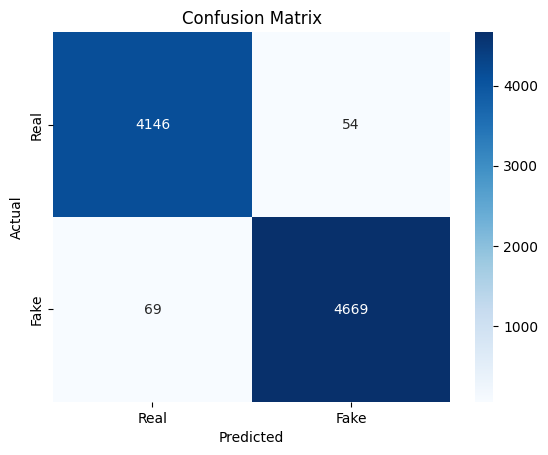

In [169]:
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

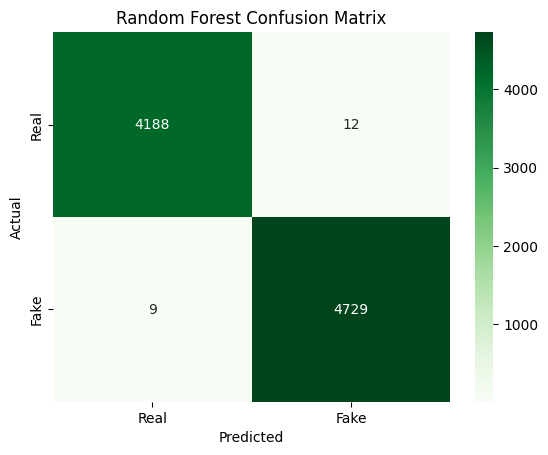

In [170]:
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [171]:
sample = "Hillary Clinton was secretly running a criminal operation"

cleaned = clean_text(sample)
tfidf_features = vectorizer.transform([cleaned])
extra_features = np.array([[
    sample.count('!'),
    sample.count('?'),
    sum(1 for word in sample.split() if word.isupper())
]])
combined = hstack([tfidf_features, extra_features])
prediction = rf_model.predict(combined)
print('Prediction:', 'Fake' if prediction[0] == 1 else 'Real')

Prediction: Fake


In [172]:
joblib.dump(rf_model, 'fake_news_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')
print('Model and vectorizer saved!')

Model and vectorizer saved!
